# CM1 模式水平风场剖面图绘制

本 Notebook 演示如何读取 CM1 模式输出的 NetCDF 数据，确定台风中心，并绘制指定高度和时刻的水平风场剖面图。
主要包含：
1.  计算/读取台风中心位置。
2.  网格去交错 (Destaggering)。
3.  计算径向风速 (Radial Velocity)。
4.  绘制风矢量 (Quiver) 和径向风速填色图 (Contourf)。

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import sys
import os
import importlib
from matplotlib.colors import BoundaryNorm

# 添加当前目录到 sys.path 以便导入本地模块
current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.append(current_dir)

try:
    import cm1_psfc_min_smoother as cps
    importlib.reload(cps)  # 确保载入最新版本
    from cm1_psfc_min_smoother import find_smoothed_min_point, find_smoothed_min_prs
    print("成功导入 find_smoothed_min_point / find_smoothed_min_prs 模块")
except ImportError as e:
    print(f"警告: 无法导入 cm1_psfc_min_smoother 模块: {e}")
    # 定义简单替代函数用于测试（如果模块不存在）
    def find_smoothed_min_point(nc_file, time_key, **kwargs):
        return {'x': 0.0, 'y': 0.0, 'ix': 250, 'iy': 250}
    def find_smoothed_min_prs(nc_file, time_key, target_zh, **kwargs):
        return {'x': 0.0, 'y': 0.0, 'ix': 250, 'iy': 250, 'z_value': target_zh}

# --------------------------
# 1. 参数设置
# --------------------------
nc_file = "dataset/cm1out.nc" # 请修改为您的实际 nc 文件路径，例如 "dataset/cm1out.nc"
# 注意：用户描述中提到输出为 .nc 文件，且有 u, v, w 变量。
# 如果使用的是原始 cm1out.nc，请更改此处文件名。
nc_file_path = "dataset/cm1out.nc" 
target_time_hours = 72.0  # 指定时间 (小时)
target_time = target_time_hours * 3600.0  # 指定时间 (秒)
target_height_km = 12  # 指定高度 (km)
crop_radius_km = 50.0  # 裁剪半径 (km)

print(f"处理文件: {nc_file_path}")
print(f"目标时间: {target_time} s")
print(f"目标高度: {target_height_km} km")

成功导入 find_smoothed_min_point / find_smoothed_min_prs 模块
处理文件: dataset/cm1out.nc
目标时间: 259200.0 s
目标高度: 12 km


In [13]:
# --------------------------
# 2. 确定台风中心
# --------------------------
# 使用 find_smoothed_min_prs 在指定高度的气压场上确定中心
try:
    center_info = find_smoothed_min_prs(nc_file_path, target_time, target_height_km, var_name='prs')
    center_x = center_info['x']
    center_y = center_info['y']
    print(f"计算得到的台风中心: x={center_x:.2f} km, y={center_y:.2f} km (z≈{center_info.get('z_value', target_height_km):.2f} km)")
except Exception as e:
    print(f"计算中心时出错: {e}")
    print("尝试使用默认中心 (0,0)")
    center_x = 0.0
    center_y = 0.0
center_x-=2.5
center_y+=2.5
# --------------------------
# 3. 读取数据与去交错
# --------------------------
with Dataset(nc_file_path, 'r') as nc:
    # 读取坐标
    xh = nc.variables['xh'][:]
    yh = nc.variables['yh'][:]
    zh = nc.variables['zh'][:]
    time_arr = nc.variables['time'][:]
    
    # 找到最近的时间索引和高度索引
    t_idx = np.argmin(np.abs(time_arr - target_time))
    z_idx = np.argmin(np.abs(zh - target_height_km))
    
    actual_time = time_arr[t_idx]
    actual_height = zh[z_idx]
    print(f"实际读取时间: {actual_time} s (Index: {t_idx})")
    print(f"实际读取高度: {actual_height} km (Index: {z_idx})")
    
    # 读取风场数据 (time, z, y, x)
    # u: (time, zh, yh, xf) -> 需要插值到 xh
    # v: (time, zh, yf, xh) -> 需要插值到 yh
    # w: (time, zf, yh, xh) -> 垂直速度通常定义在 zf，这里我们读取最接近 zh 的层或者插值
    # 注意：用户描述中 u 的维度是 (time, zh, yh, xf)，v 是 (time, zh, yf, xh)
    
    print("正在读取 u, v 数据...")
    u_stag = nc.variables['u'][t_idx, z_idx, :, :] # (yh, xf)
    v_stag = nc.variables['v'][t_idx, z_idx, :, :] # (yf, xh)
    
    # 读取 w (如果需要绘制垂直速度，或者仅作为参考)
    # w 通常定义在 zf，这里简单起见读取对应层
    # w_stag = nc.variables['w'][t_idx, z_idx, :, :] 


# 去交错 (Destaggering) 到标量网格 (xh, yh)
# u(yh, xf) -> u(yh, xh)
if u_stag.shape[1] == len(xh) + 1:
    u_destag = 0.5 * (u_stag[:, :-1] + u_stag[:, 1:])
else:
    u_destag = 0.5 * (u_stag[:, :-1] + u_stag[:, 1:]) # 视具体边界情况而定，通常 C-grid xf 比 xh 多 1

# v(yf, xh) -> v(yh, xh)
if v_stag.shape[0] == len(yh) + 1:
    v_destag = 0.5 * (v_stag[:-1, :] + v_stag[1:, :])
else:
    v_destag = 0.5 * (v_stag[:-1, :] + v_stag[1:, :])

print(f"去交错后 u 形状: {u_destag.shape}")
print(f"去交错后 v 形状: {v_destag.shape}")

计算得到的台风中心: x=-4.50 km, y=-10.50 km (z≈11.75 km)
实际读取时间: 259200.0 s (Index: 72)
实际读取高度: 11.750000953674316 km (Index: 32)
正在读取 u, v 数据...
去交错后 u 形状: (500, 500)
去交错后 v 形状: (500, 500)


In [14]:
# --------------------------
# 4. 计算径向风速与裁剪区域
# --------------------------
# 创建网格
X, Y = np.meshgrid(xh, yh)

# 计算相对于台风中心的坐标
dX = X - center_x
dY = Y - center_y

# 计算距离和角度
R = np.sqrt(dX**2 + dY**2)
Theta = np.arctan2(dY, dX) # 弧度

# 计算径向风速 Vr
# Vr = u * cos(theta) + v * sin(theta)
# Outflow (出流) > 0, Inflow (入流) < 0
Vr = u_destag * np.cos(Theta) + v_destag * np.sin(Theta)

# 裁剪数据 (正负 200km)
mask_x = (xh >= center_x - crop_radius_km) & (xh <= center_x + crop_radius_km)
mask_y = (yh >= center_y - crop_radius_km) & (yh <= center_y + crop_radius_km)

# 获取裁剪后的索引
ix_start, ix_end = np.where(mask_x)[0][0], np.where(mask_x)[0][-1]
iy_start, iy_end = np.where(mask_y)[0][0], np.where(mask_y)[0][-1]

# 裁剪数组
X_crop = X[iy_start:iy_end+1, ix_start:ix_end+1]
Y_crop = Y[iy_start:iy_end+1, ix_start:ix_end+1]
u_crop = u_destag[iy_start:iy_end+1, ix_start:ix_end+1]
v_crop = v_destag[iy_start:iy_end+1, ix_start:ix_end+1]
Vr_crop = Vr[iy_start:iy_end+1, ix_start:ix_end+1]

# 将坐标转换为相对于中心的坐标 (用于绘图)
X_rel = X_crop - center_x
Y_rel = Y_crop - center_y

print(f"裁剪后网格大小: {X_crop.shape}")

裁剪后网格大小: (33, 33)


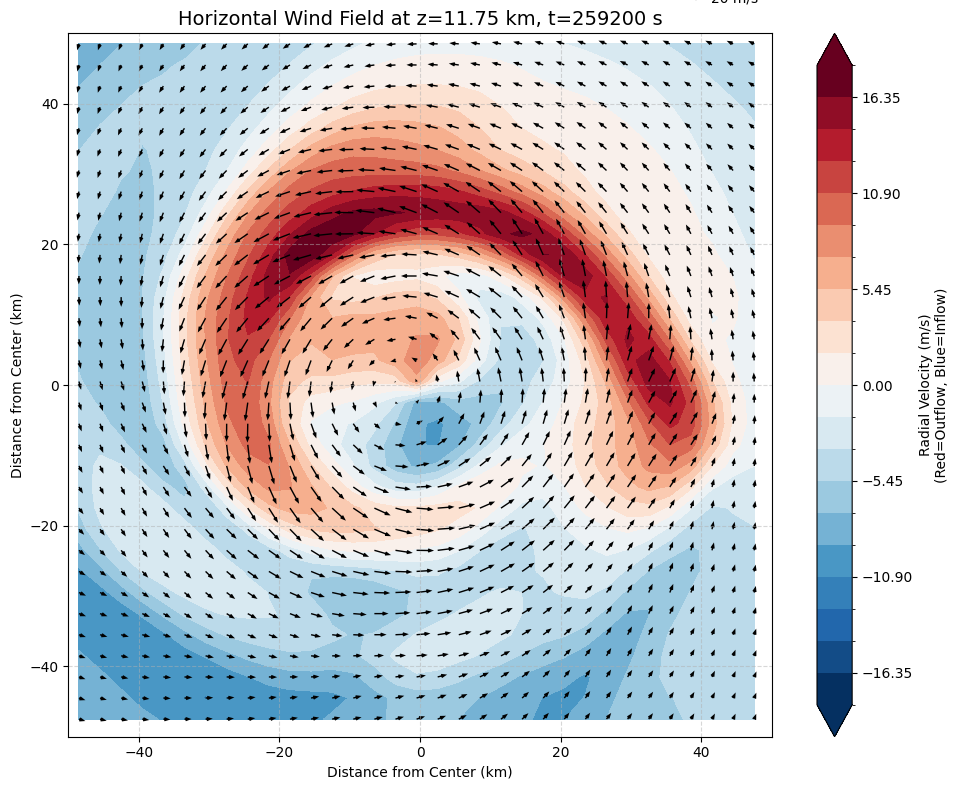

In [15]:
# --------------------------
# 5. 绘制水平风场剖面图
# --------------------------
fig, ax = plt.subplots(figsize=(10, 8))

# 设置离散的 Colormap
# 红色表示出流 (>0), 蓝色表示入流 (<0)
cmap = plt.get_cmap('RdBu_r')
# 定义离散的层级 (Levels)
# 根据数据范围调整，这里假设径向风速在 -30 到 30 m/s 之间
v_max = np.max(np.abs(Vr_crop))
levels = np.linspace(-v_max, v_max, 21) # 21个层级
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

# 1. 绘制径向风速填色图
cf = ax.contourf(X_rel, Y_rel, Vr_crop, levels=levels, cmap=cmap, norm=norm, extend='both')

# 添加 Colorbar
cbar = plt.colorbar(cf, ax=ax, label='Radial Velocity (m/s)\n(Red=Outflow, Blue=Inflow)')

# 2. 绘制风矢量 (Quiver)
# 为了避免箭头过密，进行降采样 (Skip)
skip = int(len(X_rel) / 30) # 保持大约 30x30 个箭头
if skip < 1: skip = 1

Q = ax.quiver(X_rel[::skip, ::skip], Y_rel[::skip, ::skip], 
              u_crop[::skip, ::skip], v_crop[::skip, ::skip],
              scale=None, # 自动缩放
              color='black', 
              width=0.002,
              headwidth=3, 
              headlength=4)

# 添加 Quiver Key (参考箭头)
qk = ax.quiverkey(Q, 0.9, 1.05, 20, '20 m/s', labelpos='E', coordinates='axes')

# 设置坐标轴
ax.set_xlim(-crop_radius_km, crop_radius_km)
ax.set_ylim(-crop_radius_km, crop_radius_km)
ax.set_xlabel('Distance from Center (km)')
ax.set_ylabel('Distance from Center (km)')
ax.set_title(f'Horizontal Wind Field at z={actual_height:.2f} km, t={actual_time:.0f} s', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_aspect('equal') # 保持正方形比例

plt.tight_layout()
plt.show()

In [16]:
# 批量输出水平风场：从 30h 开始每 6h 输出一次，直到 72h
import numpy as np
import os

# 时间序列（小时）
time_list_hours = np.arange(30, 72 + 1e-6, 6)
os.makedirs("figure", exist_ok=True)

for th in time_list_hours:
    target_time = th * 3600.0  # 秒

    # 1) 在指定高度的气压场上计算中心
    try:
        center_info = find_smoothed_min_prs(nc_file_path, target_time, target_height_km, var_name="prs")
        center_x = center_info["x"]
        center_y = center_info["y"]
    except Exception as e:
        print(f"time={th}h 计算中心失败: {e}，使用 (0,0)")
        center_x = 0.0
        center_y = 0.0
    center_x,center_y=center_y,center_x
    # 2) 读取指定时间/高度的 u,v 并去交错
    with Dataset(nc_file_path, "r") as nc:
        xh = nc.variables["xh"][:]
        yh = nc.variables["yh"][:]
        zh = nc.variables["zh"][:]
        time_arr = nc.variables["time"][:]

        t_idx = int(np.argmin(np.abs(time_arr - target_time)))
        z_idx = int(np.argmin(np.abs(zh - target_height_km)))

        actual_time = float(time_arr[t_idx])
        actual_height = float(zh[z_idx])

        u_stag = nc.variables["u"][t_idx, z_idx, :, :]
        v_stag = nc.variables["v"][t_idx, z_idx, :, :]

    # destagger u: (yh, xf) -> (yh, xh)
    if u_stag.shape[1] == len(xh) + 1:
        u_destag = 0.5 * (u_stag[:, :-1] + u_stag[:, 1:])
    else:
        u_destag = 0.5 * (u_stag[:, :-1] + u_stag[:, 1:])

    # destagger v: (yf, xh) -> (yh, xh)
    if v_stag.shape[0] == len(yh) + 1:
        v_destag = 0.5 * (v_stag[:-1, :] + v_stag[1:, :])
    else:
        v_destag = 0.5 * (v_stag[:-1, :] + v_stag[1:, :])

    # 3) 计算 Vr 并裁剪
    X, Y = np.meshgrid(xh, yh)
    dX = X - center_x
    dY = Y - center_y
    Theta = np.arctan2(dY, dX)
    Vr = u_destag * np.cos(Theta) + v_destag * np.sin(Theta)

    mask_x = (xh >= center_x - crop_radius_km) & (xh <= center_x + crop_radius_km)
    mask_y = (yh >= center_y - crop_radius_km) & (yh <= center_y + crop_radius_km)
    ix_start, ix_end = np.where(mask_x)[0][0], np.where(mask_x)[0][-1]
    iy_start, iy_end = np.where(mask_y)[0][0], np.where(mask_y)[0][-1]

    X_rel = X[iy_start:iy_end+1, ix_start:ix_end+1] - center_x
    Y_rel = Y[iy_start:iy_end+1, ix_start:ix_end+1] - center_y
    Vr_crop = Vr[iy_start:iy_end+1, ix_start:ix_end+1]
    u_crop = u_destag[iy_start:iy_end+1, ix_start:ix_end+1]
    v_crop = v_destag[iy_start:iy_end+1, ix_start:ix_end+1]

    # 4) 绘图
    fig, ax = plt.subplots(figsize=(10, 8))
    cmap = plt.get_cmap('RdBu_r')
    v_max = np.max(np.abs(Vr_crop)) if np.isfinite(Vr_crop).any() else 1.0
    levels = np.linspace(-v_max, v_max, 21)
    norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

    cf = ax.contourf(X_rel, Y_rel, Vr_crop, levels=levels, cmap=cmap, norm=norm, extend='both')
    cbar = plt.colorbar(cf, ax=ax, label='Radial Velocity (m/s)\n(Red=Outflow, Blue=Inflow)')

    skip = max(1, int(min(X_rel.shape) / 30))
    Q = ax.quiver(X_rel[::skip, ::skip], Y_rel[::skip, ::skip],
                  u_crop[::skip, ::skip], v_crop[::skip, ::skip],
                  scale=None, color='black', width=0.002, headwidth=3, headlength=4)
    ax.quiverkey(Q, 0.9, 1.05, 20, '20 m/s', labelpos='E', coordinates='axes')

    ax.set_xlim(-crop_radius_km, crop_radius_km)
    ax.set_ylim(-crop_radius_km, crop_radius_km)
    ax.set_xlabel('Distance from Center (km)')
    ax.set_ylabel('Distance from Center (km)')
    ax.set_title(f'Horizontal Wind Field at z={actual_height:.2f} km, t={actual_time:.0f} s ({th:.0f} h)', fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_aspect('equal')

    plt.tight_layout()

    outfile = os.path.join('figure', f'hwind_t{int(th):03d}h.png')
    fig.savefig(outfile, dpi=200)
    plt.close(fig)
    print(f'saved: {outfile}')

saved: figure\hwind_t030h.png
saved: figure\hwind_t036h.png
saved: figure\hwind_t042h.png
saved: figure\hwind_t048h.png
saved: figure\hwind_t054h.png
saved: figure\hwind_t060h.png
saved: figure\hwind_t066h.png
saved: figure\hwind_t072h.png
